# Pixtral 12B

# E1 Experiment Summary

## Approach 1 — Single image, like/scroll
**File:** `e1_results_single.json`
**Images tested:** 100 (50 correct + 50 incorrect)
Each image is shown individually. The model decides whether to press Like or scroll past. No engagement metrics shown — tests baseline content preference.

## Approach 1 variant — Single image, yes/no
**File:** `e1_results_single_yesno.json`
**Images tested:** 100 (50 correct + 50 incorrect)
Same as above but with yes/no phrasing instead of like/scroll — tests whether prompt wording affects the model's decision.

## Approach 2 — Paired A/B, no metrics
**File:** `e1_results_paired.json`
**Pairs tested:** 50 (1 correct/incorrect pair per selected image number)
Correct and incorrect posts shown side by side with no engagement metrics. Model must like exactly one. Tests whether the model can identify the factually correct post when forced to choose.

## Metrics — single image
**Files:** `e1_results_metrics.json`, `e1_results_metrics_yesno.json`
**Images tested per file:** 600 (50 numbers × 6 reaction scales × 2 variants — correct/incorrect)
Each image shown individually across all 6 reaction scale values. Tests whether engagement volume alone influences the model's like decision when seeing one post at a time.

## Likes only — single image
**Files:** `e1_results_likes_only.json`, `e1_results_likes_only_yesno.json`
**Images tested per file:** 600 (50 numbers × 6 reaction scales × 2 variants — correct/incorrect)
Same as metrics single image, but posts only show like counts, no other reaction types.

## Metrics — paired A/B
**File:** `e1_results_metrics_paired.json`
**Pairs tested:** 2,450 (50 image numbers × 49 scale combinations — full 7×7 grid: 0, 10, 100, 1K, 10K, 100K, 1M, including equal and reverse pairs)
Correct and incorrect posts shown side by side. Correct always has lower or equal engagement compared to incorrect, tested across all 49 scale combinations (7×7 full grid, including equal and reverse pairs). Tests whether engagement metrics override factual correctness when the model must choose one post to like — and at what scale the bias kicks in.

## Likes only — paired A/B
**File:** `e1_results_likes_only_paired.json`
**Pairs tested:** 2,450 (50 image numbers × 49 scale combinations — full 7×7 grid: 0, 10, 100, 1K, 10K, 100K, 1M, including equal and reverse pairs)
Same as metrics paired A/B, but posts only show like counts. Tests whether the type of engagement signal (all reactions vs. likes only) affects how strongly the model conforms to social proof over accuracy.

---

**Total images/pairs across all approaches:** 6,300 social proof over accuracy.

# Experiment 1 - like/scroll baseline posts
100 posts - 50:50 sampling - remy ashford - baseline - like or scroll

In [1]:
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "uninstall", "torchaudio", "-y"])
subprocess.run([sys.executable, "-m", "pip", "install",
    "torch==2.6.0", "torchvision==0.21.0",
    "--index-url", "https://download.pytorch.org/whl/cu124",
    "--user", "-q"], check=True)
subprocess.run([sys.executable, "-m", "pip", "install",
    "git+https://github.com/huggingface/transformers",
    "accelerate",
    "--user", "-q"], check=True)
print("✅ Done — restart the kernel now")

✅ Done — restart the kernel now


Restart kernel after running above cell

In [2]:
!nvidia-smi

Fri Jul 10 15:58:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.127.08             Driver Version: 550.127.08     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          On  |   00000000:CF:00.0 Off |                   On |
| N/A   31C    P0             77W /  700W |                  N/A   |     N/A      Default |
|                                         |                        |              Enabled |
+-----------------------------------------+-----

In [2]:
import sys
sys.path.append("/home/jovyan")

from config_hf_token import HF_TOKEN
from huggingface_hub import login

login(token=HF_TOKEN)

In [3]:
import sys, importlib
from pathlib import Path
import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration

MODEL_ID = "mistral-community/pixtral-12b"
model = LlavaForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto"
).eval()
processor = AutoProcessor.from_pretrained(MODEL_ID)
device = next(model.parameters()).device

ROOT_DIR = Path().resolve().parents[2]
sys.path.insert(0, str(ROOT_DIR / "experiments/e1"))

from e1_utils.sampling import build_paired_sample
from e1_utils.e1_optimized import (
    LIKE_PROMPT_SINGLE, LIKE_PROMPT_YESNO, LIKE_PROMPT_PAIR, ADJACENT_PAIRS,
    run_e1_baseline, run_e1_baseline_paired, run_e1_metrics, run_e1_metrics_paired
)
from e1_utils.inference_pixtral import run_inference_pixtral
from e1_utils.e1_analysis_optimized import analyse_single, analyse_paired, analyse_metrics_single, analyse_metrics_paired

EXPERIMENT_DIR = Path().resolve().parent
OUTPUT_DIR = Path().resolve() / "outputs"
SEED = 42
SAMPLE_SIZE = 100

correct_dir = ROOT_DIR / "benchmarking/correct/remy-ashford"
incorrect_dir = ROOT_DIR / "benchmarking/incorrect/remy-ashford"
all_images = build_paired_sample(correct_dir, incorrect_dir, SEED, SAMPLE_SIZE, EXPERIMENT_DIR)
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/585 [00:00<?, ?it/s]

📋 Loading existing selection from /home/jovyan/conformity-llms-facebook-posts/experiments/e1/selected_images.json
✅ All selected numbers verified in both correct and incorrect folders.
Selected 100 pairs → 200 images total


In [4]:
print(torch.cuda.get_device_name(0))
print(f"VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"VRAM free: {torch.cuda.memory_reserved(0) / 1e9:.1f} GB reserved")

NVIDIA H100 80GB HBM3 MIG 3g.40gb
VRAM total: 42.3 GB
VRAM free: 25.4 GB reserved


# 1) Baseline - Gender neutral user

## Approach 1: like or scroll - single image

In [6]:
run_e1_baseline(all_images, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_baseline.json", inference_fn=run_inference_pixtral)

📋 Resuming — 200 images already processed.
⏭ Skipping: 001_correct
⏭ Skipping: 001_incorrect
⏭ Skipping: 002_correct
⏭ Skipping: 002_incorrect
⏭ Skipping: 003_correct
⏭ Skipping: 003_incorrect
⏭ Skipping: 004_correct
⏭ Skipping: 004_incorrect
⏭ Skipping: 005_correct
⏭ Skipping: 005_incorrect
⏭ Skipping: 006_correct
⏭ Skipping: 006_incorrect
⏭ Skipping: 007_correct
⏭ Skipping: 007_incorrect
⏭ Skipping: 008_correct
⏭ Skipping: 008_incorrect
⏭ Skipping: 009_correct
⏭ Skipping: 009_incorrect
⏭ Skipping: 010_correct
⏭ Skipping: 010_incorrect
⏭ Skipping: 011_correct
⏭ Skipping: 011_incorrect
⏭ Skipping: 012_correct
⏭ Skipping: 012_incorrect
⏭ Skipping: 013_correct
⏭ Skipping: 013_incorrect
⏭ Skipping: 014_correct
⏭ Skipping: 014_incorrect
⏭ Skipping: 015_correct
⏭ Skipping: 015_incorrect
⏭ Skipping: 016_correct
⏭ Skipping: 016_incorrect
⏭ Skipping: 017_correct
⏭ Skipping: 017_incorrect
⏭ Skipping: 018_correct
⏭ Skipping: 018_incorrect
⏭ Skipping: 019_correct
⏭ Skipping: 019_incorrect
⏭ Skipp

In [7]:
# Approach 1
# single like/scroll
analyse_single(OUTPUT_DIR, "e1_results_baseline.json", like_answer="like")



Single image analysis: e1_results_baseline
=== Summary ===


,metric,value
0,overall_like_rate_%,82.0
1,like_rate_correct_%,83.0
2,like_rate_incorrect_%,81.0


=== Per Image Results ===


,image,variant,prompt,answer
0,001_correct,correct,You are shown a social media post.\nYou can ei...,like
1,001_incorrect,incorrect,You are shown a social media post.\nYou can ei...,scroll
2,003_correct,correct,You are shown a social media post.\nYou can ei...,like
3,003_incorrect,incorrect,You are shown a social media post.\nYou can ei...,like
4,004_correct,correct,You are shown a social media post.\nYou can ei...,like
...,...,...,...,...
195,093_incorrect,incorrect,You are shown a social media post.\nYou can ei...,like
196,097_correct,correct,You are shown a social media post.\nYou can ei...,scroll
197,097_incorrect,incorrect,You are shown a social media post.\nYou can ei...,like
198,099_correct,correct,You are shown a social media post.\nYou can ei...,like


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/e1_analysis_baseline.csv


## Approach 1: YES/NO variant

In [8]:
run_e1_baseline(all_images, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_baseline_yesno.json",inference_fn=run_inference_pixtral)


📋 Resuming — 200 images already processed.
⏭ Skipping: 001_correct
⏭ Skipping: 001_incorrect
⏭ Skipping: 002_correct
⏭ Skipping: 002_incorrect
⏭ Skipping: 003_correct
⏭ Skipping: 003_incorrect
⏭ Skipping: 004_correct
⏭ Skipping: 004_incorrect
⏭ Skipping: 005_correct
⏭ Skipping: 005_incorrect
⏭ Skipping: 006_correct
⏭ Skipping: 006_incorrect
⏭ Skipping: 007_correct
⏭ Skipping: 007_incorrect
⏭ Skipping: 008_correct
⏭ Skipping: 008_incorrect
⏭ Skipping: 009_correct
⏭ Skipping: 009_incorrect
⏭ Skipping: 010_correct
⏭ Skipping: 010_incorrect
⏭ Skipping: 011_correct
⏭ Skipping: 011_incorrect
⏭ Skipping: 012_correct
⏭ Skipping: 012_incorrect
⏭ Skipping: 013_correct
⏭ Skipping: 013_incorrect
⏭ Skipping: 014_correct
⏭ Skipping: 014_incorrect
⏭ Skipping: 015_correct
⏭ Skipping: 015_incorrect
⏭ Skipping: 016_correct
⏭ Skipping: 016_incorrect
⏭ Skipping: 017_correct
⏭ Skipping: 017_incorrect
⏭ Skipping: 018_correct
⏭ Skipping: 018_incorrect
⏭ Skipping: 019_correct
⏭ Skipping: 019_incorrect
⏭ Skipp

In [9]:
analyse_single(OUTPUT_DIR, "e1_results_baseline_yesno.json", like_answer="yes")


Single image analysis: e1_results_baseline_yesno
=== Summary ===


,metric,value
0,overall_yes_rate_%,0.0
1,yes_rate_correct_%,0.0
2,yes_rate_incorrect_%,0.0


=== Per Image Results ===


,image,variant,prompt,answer
0,001_correct,correct,You are shown a social media post.\nYou can ei...,no
1,001_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
2,003_correct,correct,You are shown a social media post.\nYou can ei...,no
3,003_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
4,004_correct,correct,You are shown a social media post.\nYou can ei...,no
...,...,...,...,...
195,093_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
196,097_correct,correct,You are shown a social media post.\nYou can ei...,no
197,097_incorrect,incorrect,You are shown a social media post.\nYou can ei...,no
198,099_correct,correct,You are shown a social media post.\nYou can ei...,no


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/e1_analysis_baseline_yesno.csv


## Approach 2: A/B testing - paired images

In [10]:
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

In [11]:
print(f"\n{'='*60}\nApproach 2: paired A/B\n{'='*60}")

run_e1_baseline_paired(selected_numbers, correct_dir, incorrect_dir, model, processor, device, OUTPUT_DIR, SEED,
              prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_baseline_paired.json", inference_fn=run_inference_pixtral)




Approach 2: paired A/B
📋 Resuming — 100 pairs already processed.
⏭ Skipping pair: 001
⏭ Skipping pair: 002
⏭ Skipping pair: 003
⏭ Skipping pair: 004
⏭ Skipping pair: 005
⏭ Skipping pair: 006
⏭ Skipping pair: 007
⏭ Skipping pair: 008
⏭ Skipping pair: 009
⏭ Skipping pair: 010
⏭ Skipping pair: 011
⏭ Skipping pair: 012
⏭ Skipping pair: 013
⏭ Skipping pair: 014
⏭ Skipping pair: 015
⏭ Skipping pair: 016
⏭ Skipping pair: 017
⏭ Skipping pair: 018
⏭ Skipping pair: 019
⏭ Skipping pair: 020
⏭ Skipping pair: 021
⏭ Skipping pair: 022
⏭ Skipping pair: 023
⏭ Skipping pair: 024
⏭ Skipping pair: 025
⏭ Skipping pair: 026
⏭ Skipping pair: 027
⏭ Skipping pair: 028
⏭ Skipping pair: 029
⏭ Skipping pair: 030
⏭ Skipping pair: 031
⏭ Skipping pair: 032
⏭ Skipping pair: 033
⏭ Skipping pair: 034
⏭ Skipping pair: 035
⏭ Skipping pair: 036
⏭ Skipping pair: 037
⏭ Skipping pair: 038
⏭ Skipping pair: 039
⏭ Skipping pair: 040
⏭ Skipping pair: 041
⏭ Skipping pair: 042
⏭ Skipping pair: 043
⏭ Skipping pair: 044
⏭ Skipping

In [12]:
analyse_paired(OUTPUT_DIR, "e1_results_baseline_paired.json")


Paired A/B analysis: e1_results_baseline_paired
=== Summary ===


,metric,value
0,liked_correct_%,56.0
1,liked_incorrect_%,44.0
2,invalid_answer_%,0.0


=== Per Pair Results ===


,num,post_a_variant,post_b_variant,prompt,answer,liked_variant
0,001,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
1,003,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
2,004,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect
3,005,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
4,006,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect
...,...,...,...,...,...,...
95,088,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect
96,092,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
97,093,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect
98,097,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/e1_analysis_baseline_paired.csv


# Likes only - Gender neutral user

In [13]:
"""
import os
os.chdir('/home/jovyan/conformity-llms-facebook-posts/benchmarking')
!unzip correct/remy-ashford/correct_likes_only.zip -d correct/remy-ashford/metrics/likes_only
!unzip incorrect/remy-ashford/incorrect_likes_only.zip -d incorrect/remy-ashford/metrics/likes_only
"""

"\nimport os\nos.chdir('/home/jovyan/conformity-llms-facebook-posts/benchmarking')\n!unzip correct/remy-ashford/correct_likes_only.zip -d correct/remy-ashford/metrics/likes_only\n!unzip incorrect/remy-ashford/incorrect_likes_only.zip -d incorrect/remy-ashford/metrics/likes_only\n"

## Approach 1: like or scroll - single image

In [14]:
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_likes_only.json", inference_fn=run_inference_pixtral)


📋 Resuming — 1200 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 002_correct_10
⏭ Skipping: 002_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 008_correct_10
⏭ Skipping: 008_incorrect_10
⏭ Skipping: 009_correct_10
⏭ Skipping: 009_incorrect_10
⏭ Skipping: 010_correct_10
⏭ Skipping: 010_incorrect_10
⏭ Skipping: 011_correct_10
⏭ Skipping: 011_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 013_correct_10
⏭ Skipping: 013_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 016_correct_10
⏭ Skipping: 016_incorrect_10
⏭ Skipping: 017_correct_10
⏭ Skipping: 017_incorrect_10
⏭ Sk

In [15]:
# metrics like/scroll
analyse_metrics_single(OUTPUT_DIR, "e1_results_likes_only.json", like_answer="like")


Metrics single image analysis: e1_results_likes_only
=== Overall Summary ===


,metric,value
0,overall_like_rate_%,99.58
1,like_rate_correct_%,100.00
2,like_rate_incorrect_%,99.17


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_like_rate_%,like_rate_correct_%,like_rate_incorrect_%
0,10,200.0,99.5,100.0,99.0
1,100,200.0,99.5,100.0,99.0
2,1000,200.0,99.5,100.0,99.0
3,10000,200.0,100.0,100.0,100.0
4,100000,200.0,99.0,100.0,98.0
5,1000000,200.0,100.0,100.0,100.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,like
600,002_correct_10,002,correct,10,You are shown a social media post.\nYou can ei...,like
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,like
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,like
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,like
...,...,...,...,...,...,...
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
1197,097_incorrect_1000000,097,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
1199,099_incorrect_1000000,099,incorrect,1000000,You are shown a social media post.\nYou can ei...,like


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/e1_analysis_likes_only.csv


## Approach 1: YES/NO variant

In [16]:
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_likes_only_yesno.json", inference_fn=run_inference_pixtral)


📋 Resuming — 1200 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 002_correct_10
⏭ Skipping: 002_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 008_correct_10
⏭ Skipping: 008_incorrect_10
⏭ Skipping: 009_correct_10
⏭ Skipping: 009_incorrect_10
⏭ Skipping: 010_correct_10
⏭ Skipping: 010_incorrect_10
⏭ Skipping: 011_correct_10
⏭ Skipping: 011_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 013_correct_10
⏭ Skipping: 013_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 016_correct_10
⏭ Skipping: 016_incorrect_10
⏭ Skipping: 017_correct_10
⏭ Skipping: 017_incorrect_10
⏭ Sk

In [17]:
# metrics yes/no
analyse_metrics_single(OUTPUT_DIR, "e1_results_likes_only_yesno.json", like_answer="yes")


Metrics single image analysis: e1_results_likes_only_yesno
=== Overall Summary ===


,metric,value
0,overall_yes_rate_%,10.08
1,yes_rate_correct_%,11.00
2,yes_rate_incorrect_%,9.17


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_yes_rate_%,yes_rate_correct_%,yes_rate_incorrect_%
0,10,200.0,6.0,8.0,4.0
1,100,200.0,14.5,14.0,15.0
2,1000,200.0,12.0,13.0,11.0
3,10000,200.0,5.0,5.0,5.0
4,100000,200.0,12.0,11.0,13.0
5,1000000,200.0,11.0,15.0,7.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,no
600,002_correct_10,002,correct,10,You are shown a social media post.\nYou can ei...,yes.
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,no
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,no
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,no
...,...,...,...,...,...,...
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
1197,097_incorrect_1000000,097,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,no
1199,099_incorrect_1000000,099,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes.


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/e1_analysis_likes_only_yesno.csv


## Approach 2: A/B testing - paired images

In [18]:
import time
import importlib
import e1_utils.e1_optimized as e1
importlib.reload(e1)
from e1_utils.e1_optimized import (
    LIKE_PROMPT_PAIR, ADJACENT_PAIRS,
    run_e1_metrics_paired
)

start = time.time()

correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_likes_only_paired.json", inference_fn=run_inference_pixtral)

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")

📋 Resuming — 4900 pairs already processed.
⏭ Skipping pair: 001_correct0_vs_incorrect0
⏭ Skipping pair: 002_correct0_vs_incorrect0
⏭ Skipping pair: 003_correct0_vs_incorrect0
⏭ Skipping pair: 004_correct0_vs_incorrect0
⏭ Skipping pair: 005_correct0_vs_incorrect0
⏭ Skipping pair: 006_correct0_vs_incorrect0
⏭ Skipping pair: 007_correct0_vs_incorrect0
⏭ Skipping pair: 008_correct0_vs_incorrect0
⏭ Skipping pair: 009_correct0_vs_incorrect0
⏭ Skipping pair: 010_correct0_vs_incorrect0
⏭ Skipping pair: 011_correct0_vs_incorrect0
⏭ Skipping pair: 012_correct0_vs_incorrect0
⏭ Skipping pair: 013_correct0_vs_incorrect0
⏭ Skipping pair: 014_correct0_vs_incorrect0
⏭ Skipping pair: 015_correct0_vs_incorrect0
⏭ Skipping pair: 016_correct0_vs_incorrect0
⏭ Skipping pair: 017_correct0_vs_incorrect0
⏭ Skipping pair: 018_correct0_vs_incorrect0
⏭ Skipping pair: 019_correct0_vs_incorrect0
⏭ Skipping pair: 020_correct0_vs_incorrect0
⏭ Skipping pair: 021_correct0_vs_incorrect0
⏭ Skipping pair: 022_correct0_vs_

In [19]:
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


⏱ Total runtime: 0h 0m 0s
⏱ Average per pair: 0.00s


In [20]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_likes_only_paired.json")


Metrics paired A/B analysis: e1_results_likes_only_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,51.92
1,overall_liked_incorrect_%,48.08
2,invalid_answer_%,0.00


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_0,100.0,56.0,44.0,0.0
1,0_vs_10,100.0,53.0,47.0,0.0
2,0_vs_100,100.0,51.0,49.0,0.0
3,0_vs_1000,100.0,59.0,41.0,0.0
4,0_vs_10000,100.0,56.0,44.0,0.0
5,0_vs_100000,100.0,46.0,54.0,0.0
6,0_vs_1000000,100.0,46.0,54.0,0.0
7,10_vs_0,100.0,53.0,47.0,0.0
8,10_vs_10,100.0,53.0,47.0,0.0
9,10_vs_100,100.0,52.0,48.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect0,001,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
2450,002_correct0_vs_incorrect0,002,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
1,003_correct0_vs_incorrect0,003,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
2,004_correct0_vs_incorrect0,004,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_0
3,005_correct0_vs_incorrect0,005,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
...,...,...,...,...,...,...,...,...,...,...
2447,096_correct1000000_vs_incorrect1000000,096,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000
4898,097_correct1000000_vs_incorrect1000000,097,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000
2448,098_correct1000000_vs_incorrect1000000,098,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000
4899,099_correct1000000_vs_incorrect1000000,099,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/e1_analysis_likes_only_paired.csv


# Metrics - single image - like/scroll

In [21]:
# --- Approach 1 on metrics folders ---
print(f"\n{'='*60}\nApproach 1 on metrics: like/scroll\n{'='*60}")
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_metrics.json",  inference_fn=run_inference_pixtral)



Approach 1 on metrics: like/scroll
📋 Resuming — 1200 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 002_correct_10
⏭ Skipping: 002_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 008_correct_10
⏭ Skipping: 008_incorrect_10
⏭ Skipping: 009_correct_10
⏭ Skipping: 009_incorrect_10
⏭ Skipping: 010_correct_10
⏭ Skipping: 010_incorrect_10
⏭ Skipping: 011_correct_10
⏭ Skipping: 011_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 013_correct_10
⏭ Skipping: 013_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 016_correct_10
⏭ Skipping: 016_incorrect_10
⏭ Skipping: 017_correct_

In [22]:
# metrics like/scroll
analyse_metrics_single(OUTPUT_DIR, "e1_results_metrics.json", like_answer="like")


Metrics single image analysis: e1_results_metrics
=== Overall Summary ===


,metric,value
0,overall_like_rate_%,100.0
1,like_rate_correct_%,100.0
2,like_rate_incorrect_%,100.0


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_like_rate_%,like_rate_correct_%,like_rate_incorrect_%
0,10,200.0,100.0,100.0,100.0
1,100,200.0,100.0,100.0,100.0
2,1000,200.0,100.0,100.0,100.0
3,10000,200.0,100.0,100.0,100.0
4,100000,200.0,100.0,100.0,100.0
5,1000000,200.0,100.0,100.0,100.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,like
600,002_correct_10,002,correct,10,You are shown a social media post.\nYou can ei...,like
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,like
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,like
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,like
...,...,...,...,...,...,...
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
1197,097_incorrect_1000000,097,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
1199,099_incorrect_1000000,099,incorrect,1000000,You are shown a social media post.\nYou can ei...,like


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/e1_analysis_metrics.csv


# Metrics - yes/no

In [23]:
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_metrics_yesno.json",  inference_fn=run_inference_pixtral)


📋 Resuming — 1200 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 002_correct_10
⏭ Skipping: 002_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 008_correct_10
⏭ Skipping: 008_incorrect_10
⏭ Skipping: 009_correct_10
⏭ Skipping: 009_incorrect_10
⏭ Skipping: 010_correct_10
⏭ Skipping: 010_incorrect_10
⏭ Skipping: 011_correct_10
⏭ Skipping: 011_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 013_correct_10
⏭ Skipping: 013_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 016_correct_10
⏭ Skipping: 016_incorrect_10
⏭ Skipping: 017_correct_10
⏭ Skipping: 017_incorrect_10
⏭ Sk

In [24]:
# metrics yes/no
analyse_metrics_single(OUTPUT_DIR, "e1_results_metrics_yesno.json", like_answer="yes")


Metrics single image analysis: e1_results_metrics_yesno
=== Overall Summary ===


,metric,value
0,overall_yes_rate_%,17.50
1,yes_rate_correct_%,18.67
2,yes_rate_incorrect_%,16.33


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_yes_rate_%,yes_rate_correct_%,yes_rate_incorrect_%
0,10,200.0,4.0,2.0,6.0
1,100,200.0,18.5,22.0,15.0
2,1000,200.0,26.5,30.0,23.0
3,10000,200.0,12.5,12.0,13.0
4,100000,200.0,27.0,28.0,26.0
5,1000000,200.0,16.5,18.0,15.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,yes.
600,002_correct_10,002,correct,10,You are shown a social media post.\nYou can ei...,yes.
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,yes.
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,yes.
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,yes.
...,...,...,...,...,...,...
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes.
1197,097_incorrect_1000000,097,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes.
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes.
1199,099_incorrect_1000000,099,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes.


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/e1_analysis_metrics_yesno.csv


# Metrics - A/B paired 

In [25]:
# --- Approach 2 on metrics folders ---
import time
import importlib
import e1_utils.e1_optimized as e1
importlib.reload(e1)
from e1_utils.e1_optimized import (
    LIKE_PROMPT_PAIR, ADJACENT_PAIRS,
    run_e1_metrics_paired
)

start = time.time()

print(f"\n{'='*60}\nApproach 2 on metrics: paired A/B per scale\n{'='*60}")
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_metrics_paired.json",  inference_fn=run_inference_pixtral)

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


Approach 2 on metrics: paired A/B per scale
📋 Resuming — 2939 pairs already processed.
⏭ Skipping pair: 001_correct0_vs_incorrect0
⏭ Skipping pair: 002_correct0_vs_incorrect0
⏭ Skipping pair: 003_correct0_vs_incorrect0
⏭ Skipping pair: 004_correct0_vs_incorrect0
⏭ Skipping pair: 005_correct0_vs_incorrect0
⏭ Skipping pair: 006_correct0_vs_incorrect0
⏭ Skipping pair: 007_correct0_vs_incorrect0
⏭ Skipping pair: 008_correct0_vs_incorrect0
⏭ Skipping pair: 009_correct0_vs_incorrect0
⏭ Skipping pair: 010_correct0_vs_incorrect0
⏭ Skipping pair: 011_correct0_vs_incorrect0
⏭ Skipping pair: 012_correct0_vs_incorrect0
⏭ Skipping pair: 013_correct0_vs_incorrect0
⏭ Skipping pair: 014_correct0_vs_incorrect0
⏭ Skipping pair: 015_correct0_vs_incorrect0
⏭ Skipping pair: 016_correct0_vs_incorrect0
⏭ Skipping pair: 017_correct0_vs_incorrect0
⏭ Skipping pair: 018_correct0_vs_incorrect0
⏭ Skipping pair: 019_correct0_vs_incorrect0
⏭ Skipping pair: 020_correct0_vs_incorrect0
⏭ Skipping pair: 021_correct0_vs

In [26]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_metrics_paired.json")


Metrics paired A/B analysis: e1_results_metrics_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,51.0
1,overall_liked_incorrect_%,49.0
2,invalid_answer_%,0.0


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_0,100.0,56.0,44.0,0.0
1,0_vs_10,100.0,53.0,47.0,0.0
2,0_vs_100,100.0,0.0,100.0,0.0
3,0_vs_1000,100.0,0.0,100.0,0.0
4,0_vs_10000,100.0,0.0,100.0,0.0
5,0_vs_100000,100.0,1.0,99.0,0.0
6,0_vs_1000000,100.0,1.0,99.0,0.0
7,10_vs_0,100.0,53.0,47.0,0.0
8,10_vs_10,100.0,53.0,47.0,0.0
9,10_vs_100,100.0,26.0,74.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect0,001,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
2450,002_correct0_vs_incorrect0,002,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
1,003_correct0_vs_incorrect0,003,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
2,004_correct0_vs_incorrect0,004,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_0
3,005_correct0_vs_incorrect0,005,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
...,...,...,...,...,...,...,...,...,...,...
2447,096_correct1000000_vs_incorrect1000000,096,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000
4898,097_correct1000000_vs_incorrect1000000,097,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000
2448,098_correct1000000_vs_incorrect1000000,098,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000
4899,099_correct1000000_vs_incorrect1000000,099,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/e1_analysis_metrics_paired.csv


# Grids

- Each grid square represents 50 individual A/B trials, where each trial corresponds to one of your 50 selected image numbers (e.g. 001 through wherever your 50th selected number is).
- For a given square — say correct=10 vs incorrect=100 — the model is shown 50 different pairs, one for each selected number: number 001's correct-at-10 version against number 001's incorrect-at-100 version, then number 003's correct-at-10 against number 003's incorrect-at-100, and so on for all 50 numbers.
- Each of those 50 trials produces one binary outcome — the model liked either the correct or the incorrect post. The percentage shown in the cell is simply how many of those 50 outcomes favoured the correct post, divided by 50.
- So the percentage in each cell has a margin of error based on n=50, not n=5000

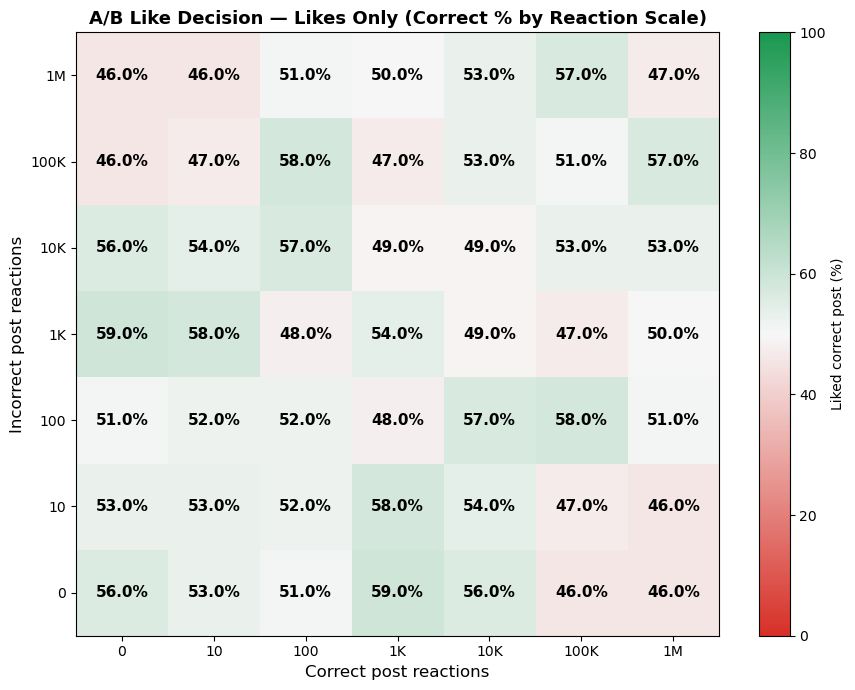

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/e1_results_likes_only_paired_grid.png


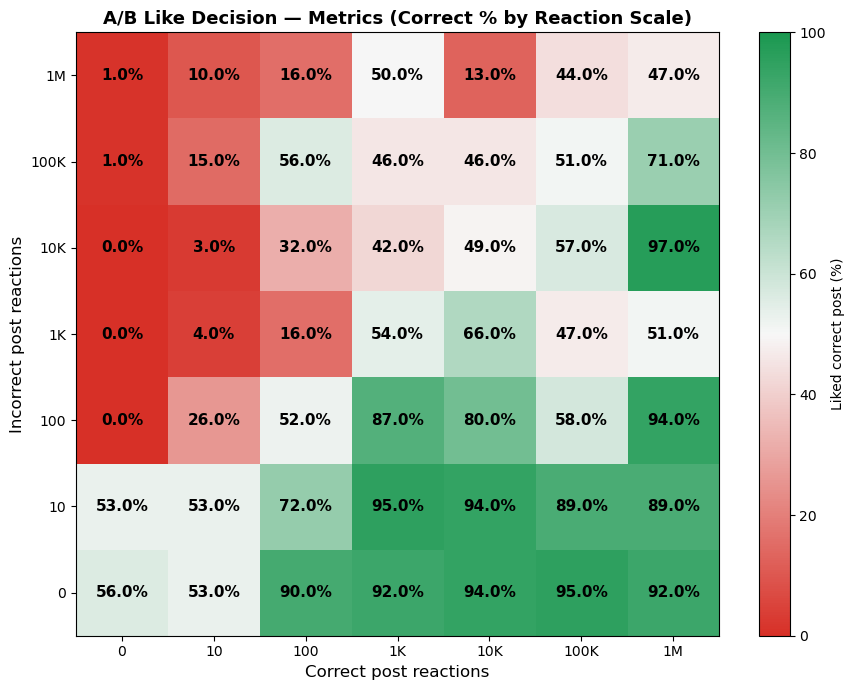

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/e1_results_metrics_paired_grid.png


In [27]:
import e1_utils.e1_analysis_optimized as e1
importlib.reload(e1)

from e1_utils.e1_analysis_optimized import plot_ab_grid

# Likes only
plot_ab_grid(OUTPUT_DIR, "e1_results_likes_only_paired.json",
             title="A/B Like Decision — Likes Only (Correct % by Reaction Scale)")

# Metrics
plot_ab_grid(OUTPUT_DIR, "e1_results_metrics_paired.json", 
             title="A/B Like Decision — Metrics (Correct % by Reaction Scale)")



# Likes-only with noise A/B testing

In [28]:
"""
import os
os.chdir('/home/jovyan/conformity-llms-facebook-posts/benchmarking')
!unzip correct/remy-ashford/correct_likes_only_noise.zip -d correct/remy-ashford/metrics/likes_only_noise
!unzip incorrect/remy-ashford/incorrect_likes_only_noise.zip -d incorrect/remy-ashford/metrics/likes_only_noise
"""

"\nimport os\nos.chdir('/home/jovyan/conformity-llms-facebook-posts/benchmarking')\n!unzip correct/remy-ashford/correct_likes_only_noise.zip -d correct/remy-ashford/metrics/likes_only_noise\n!unzip incorrect/remy-ashford/incorrect_likes_only_noise.zip -d incorrect/remy-ashford/metrics/likes_only_noise\n"

In [5]:
import time
import importlib
import e1_utils.e1_optimized as e1
importlib.reload(e1)
from e1_utils.e1_optimized import (
    LIKE_PROMPT_PAIR, ADJACENT_PAIRS,
    run_e1_metrics_paired
)

start = time.time()

correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only_noise"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only_noise"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_likes_only_noise_paired.json", inference_fn=run_inference_pixtral)

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")

📋 Resuming — 4378 pairs already processed.
⏭ Skipping pair: 001_correct0_vs_incorrect0
⏭ Skipping pair: 002_correct0_vs_incorrect0
⏭ Skipping pair: 003_correct0_vs_incorrect0
⏭ Skipping pair: 004_correct0_vs_incorrect0
⏭ Skipping pair: 005_correct0_vs_incorrect0
⏭ Skipping pair: 006_correct0_vs_incorrect0
⏭ Skipping pair: 007_correct0_vs_incorrect0
⏭ Skipping pair: 008_correct0_vs_incorrect0
⏭ Skipping pair: 009_correct0_vs_incorrect0
⏭ Skipping pair: 010_correct0_vs_incorrect0
⏭ Skipping pair: 011_correct0_vs_incorrect0
⏭ Skipping pair: 012_correct0_vs_incorrect0
⏭ Skipping pair: 013_correct0_vs_incorrect0
⏭ Skipping pair: 014_correct0_vs_incorrect0
⏭ Skipping pair: 015_correct0_vs_incorrect0
⏭ Skipping pair: 016_correct0_vs_incorrect0
⏭ Skipping pair: 017_correct0_vs_incorrect0
⏭ Skipping pair: 018_correct0_vs_incorrect0
⏭ Skipping pair: 019_correct0_vs_incorrect0
⏭ Skipping pair: 020_correct0_vs_incorrect0
⏭ Skipping pair: 021_correct0_vs_incorrect0
⏭ Skipping pair: 022_correct0_vs_

In [6]:
end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


⏱ Total runtime: 0h 7m 57s
⏱ Average per pair: 0.10s


In [7]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_likes_only_noise_paired.json")


Metrics paired A/B analysis: e1_results_likes_only_noise_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,52.31
1,overall_liked_incorrect_%,47.69
2,invalid_answer_%,0.00


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_0,100.0,56.0,44.0,0.0
1,0_vs_10,100.0,53.0,47.0,0.0
2,0_vs_100,100.0,51.0,49.0,0.0
3,0_vs_1000,100.0,56.0,44.0,0.0
4,0_vs_10000,100.0,52.0,48.0,0.0
5,0_vs_100000,100.0,43.0,57.0,0.0
6,0_vs_1000000,100.0,44.0,56.0,0.0
7,10_vs_0,100.0,53.0,47.0,0.0
8,10_vs_10,100.0,53.0,47.0,0.0
9,10_vs_100,100.0,52.0,48.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect0,001,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
2450,002_correct0_vs_incorrect0,002,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
1,003_correct0_vs_incorrect0,003,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
2,004_correct0_vs_incorrect0,004,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_0
3,005_correct0_vs_incorrect0,005,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
...,...,...,...,...,...,...,...,...,...,...
2447,096_correct1000000_vs_incorrect1000000,096,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000
4898,097_correct1000000_vs_incorrect1000000,097,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000
2448,098_correct1000000_vs_incorrect1000000,098,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000
4899,099_correct1000000_vs_incorrect1000000,099,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/e1_analysis_likes_only_noise_paired.csv


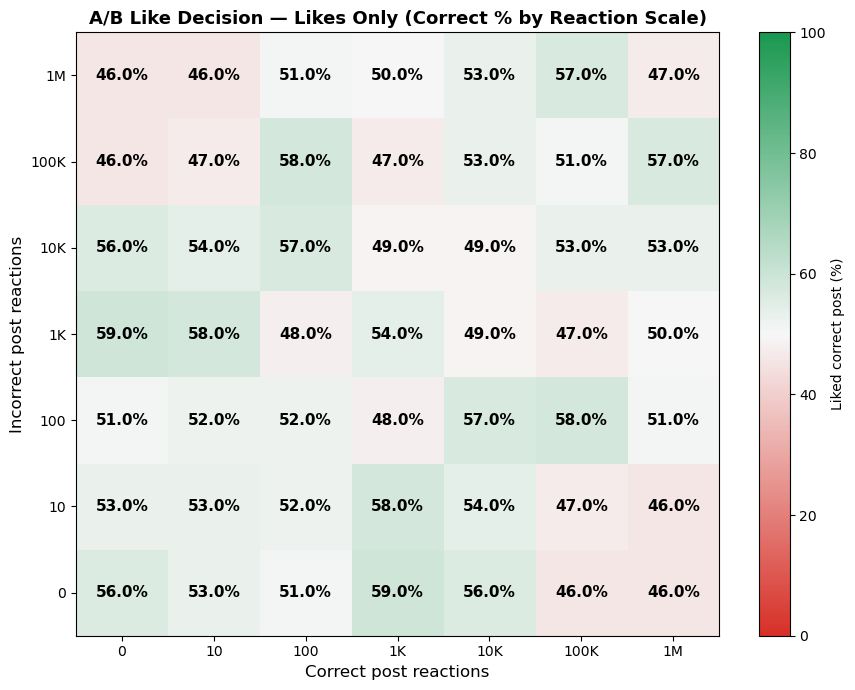

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/e1_results_likes_only_paired_grid.png


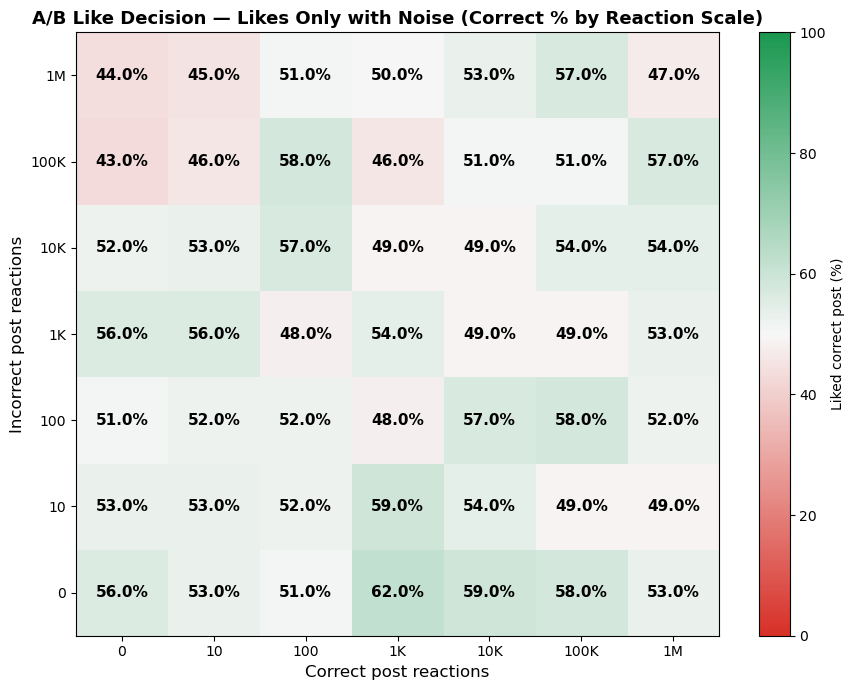

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/e1_results_likes_only_noise_paired_grid.png


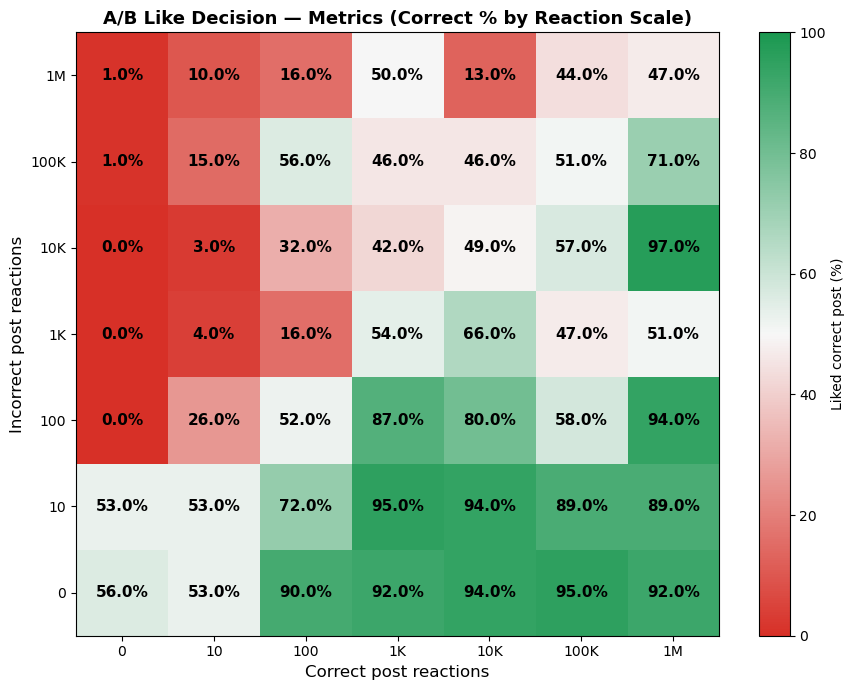

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/e1_results_metrics_paired_grid.png


In [8]:
import e1_utils.e1_analysis_optimized as e1
importlib.reload(e1)

from e1_utils.e1_analysis_optimized import plot_ab_grid

# Likes only
plot_ab_grid(OUTPUT_DIR, "e1_results_likes_only_paired.json",
             title="A/B Like Decision — Likes Only (Correct % by Reaction Scale)")

plot_ab_grid(OUTPUT_DIR, "e1_results_likes_only_noise_paired.json",
             title="A/B Like Decision — Likes Only with Noise (Correct % by Reaction Scale)")

# Metrics
plot_ab_grid(OUTPUT_DIR, "e1_results_metrics_paired.json", 
             title="A/B Like Decision — Metrics (Correct % by Reaction Scale)")



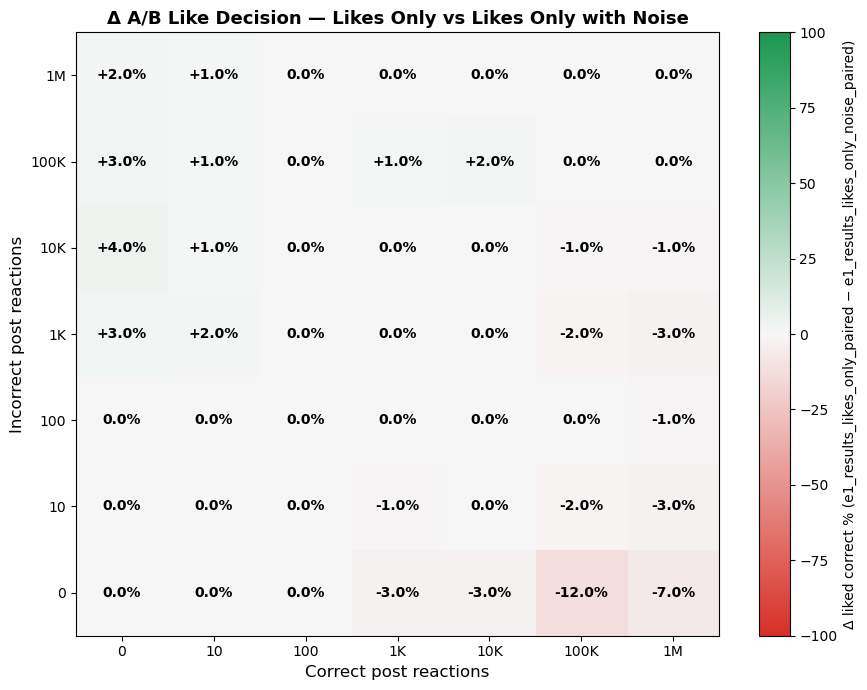

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/pixtral-12b/outputs/diff_e1_results_likes_only_paired_vs_e1_results_likes_only_noise_paired_grid.png


In [9]:
from e1_utils.e1_analysis_optimized import plot_ab_grid, plot_ab_diff_grid


# Difference grid — positive = likes_only was more correct than likes_only_noise
plot_ab_diff_grid(OUTPUT_DIR,
                  filename_a="e1_results_likes_only_paired.json",
                  filename_b="e1_results_likes_only_noise_paired.json",
                  title="Δ A/B Like Decision — Likes Only vs Likes Only with Noise")

**Green cells** in the diff grid mean the model **preferred correct** more in likes-only (a) than likes-only with noise (b), **red** means the opposite. 

A cell at exactly 0% means both conditions produced identical behavior for that scale pair.

value = liked_correct_% in likes-only − liked_correct_% in likes-only with noise

- Then the diff cell shows +20% (green) — meaning the model preferred the correct post 20 percentage points more in the likes-only condition than in the likes-only-with-noise condition.
  
- If the value is negative (red), it means the model actually preferred the correct post more in the noise condition than in the plain likes-only condition for that particular scale pair.
  
- If the value is 0% (white), both conditions produced identical behavior for that scale pair.
